# 02 - Dense bi-encoder retrieval

Each chunk is embedded with `sentence-transformers/all-MiniLM-L6-v2` and
indexed in a FAISS inner-product index. Queries are embedded the same way
and the top `k` cosine-similarity neighbors are returned.

Best for paraphrased queries where exact words don't appear in the source.
We also project the chunk embeddings to 2-D with PCA so the cluster
structure of the document is visible.

In [1]:
import os
import sys
import warnings

sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from rag.data_ingestion import chunk_documents, load_documents
from rag.embeddings import embed_texts
from rag.llm import LLM
from rag.metrics import embedding_faithfulness
from rag.pipeline import RAGPipeline
from rag.retrievers import DenseRetriever

warnings.filterwarnings('ignore')
load_dotenv(os.path.abspath('../.env'))

FILE_PATH = '../data/google_10K.pdf'
QUERY = 'How much did the company spend on research and development in each fiscal year reported, and as a percentage of revenue?'

docs = load_documents(FILE_PATH)
chunks = chunk_documents(docs, chunk_size=2000, chunk_overlap=200)
print(f'Loaded {len(docs)} pages -> {len(chunks)} chunks')

Loaded 107 pages -> 230 chunks


In [2]:
retriever = DenseRetriever()
retriever.add_documents(chunks)

for i, hit in enumerate(retriever.retrieve(QUERY, k=3), start=1):
    snippet = hit.document.page_content[:200].replace('\n', ' ')
    print(f'{i}. (cos={hit.score:.3f}) {snippet}...')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


1. (cos=0.510) 2024 2025 $ Change % Change Consolidated revenues $ 350,018  $ 402,836  $ 52,818  15 % Cost of revenues $ 146,306  $ 162,535  $ 16,229  11 % Operating expenses $ 91,322  $ 111,262  $ 19,940  22 % Oper...
2. (cos=0.509) amortization of research and development expenses. A cumulative one-time adjustment for these tax rule changes was recorded in 2023. Changes to US tax law enacted on July 4, 2025, allow for immediate ...
3. (cos=0.448) Table of Contents Alphabet Inc. Alphabet Inc. CONSOLIDATED STATEMENTS OF INCOME (in millions, except per share amounts)   Year Ended December 31,   2023 2024 2025 Revenues $ 307,394  $ 350,018  $ 402,...


## Cluster the chunk embeddings

PCA projects the 384-D embeddings to 2-D for plotting; KMeans assigns each
chunk to a cluster so that semantically similar chunks share a color. The
query embedding is shown as a black star -- nearby chunks are the ones the
retriever returns.

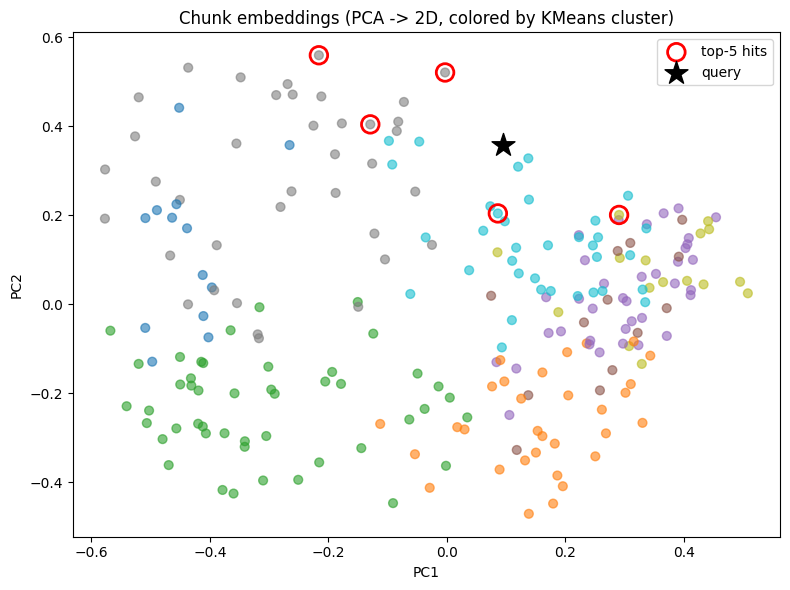

In [3]:
chunk_texts = [chunk.page_content for chunk in chunks]
chunk_emb = embed_texts(chunk_texts)
query_emb = embed_texts([QUERY])

n_clusters = min(8, len(chunks))
labels = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto').fit_predict(chunk_emb)

joint = np.vstack([chunk_emb, query_emb])
coords = PCA(n_components=2, random_state=42).fit_transform(joint)
chunk_xy, query_xy = coords[:-1], coords[-1]

top_hits = retriever.retrieve(QUERY, k=5)
top_indices = [int(hit.document.metadata['doc_id'].split('_')[1]) for hit in top_hits]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(chunk_xy[:, 0], chunk_xy[:, 1], c=labels, cmap='tab10', alpha=0.6, s=40)
ax.scatter(
    chunk_xy[top_indices, 0], chunk_xy[top_indices, 1],
    facecolors='none', edgecolors='red', s=160, linewidths=2, label='top-5 hits',
)
ax.scatter(query_xy[0], query_xy[1], marker='*', s=300, color='black', label='query')
ax.set_title('Chunk embeddings (PCA -> 2D, colored by KMeans cluster)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [4]:
llm = LLM(api_key=os.environ['GROQ_API_KEY']).get_llm(
    provider='groq',
    model_name='llama-3.3-70b-versatile',
    temperature=0.0,
)
pipeline = RAGPipeline(retriever=retriever, llm=llm, top_k=8)
response = pipeline.answer(QUERY)
print(response.answer)

The company spent $49,326 million on research and development in 2024 and $61,087 million in 2025. As a percentage of revenue, research and development expenses were 14% in 2024 and 15% in 2025 (Doc 4).


## Inline evaluation

`embedding_faithfulness` is the maximum cosine between the LLM's answer and
any of the retrieved chunks -- a quick LLM-free proxy for groundedness.

In [5]:
context_strings = [doc.page_content for doc in response.contexts]
faith = embedding_faithfulness(response.answer, context_strings)
print(f'embedding_faithfulness = {faith:.3f}')

embedding_faithfulness = 0.583
